Me falta

    graficar umap y guardarlo
    mirar cuantas dimensiones

    sacar espectros de los outliers
    graficar espectros de los outliers

    actualizar el web

In [42]:
import numpy as np
import pandas as pd
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Palatino', 'Computer Modern Roman']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 300

import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html = 'jshtml')

In [17]:
file = np.load('./data/processed/umap/umap_20211110_10256.npz', allow_pickle=True)

In [18]:
file.files

['embedding', 'labels', 'outlier_mask', 'categories', 'ids', 'petals']

In [19]:
file['categories']

array([b'QSO', b'GAL', b'GAL', ..., b'QSO', b'GAL', b'GAL'], dtype=object)

In [20]:
import matplotlib.pyplot as plt

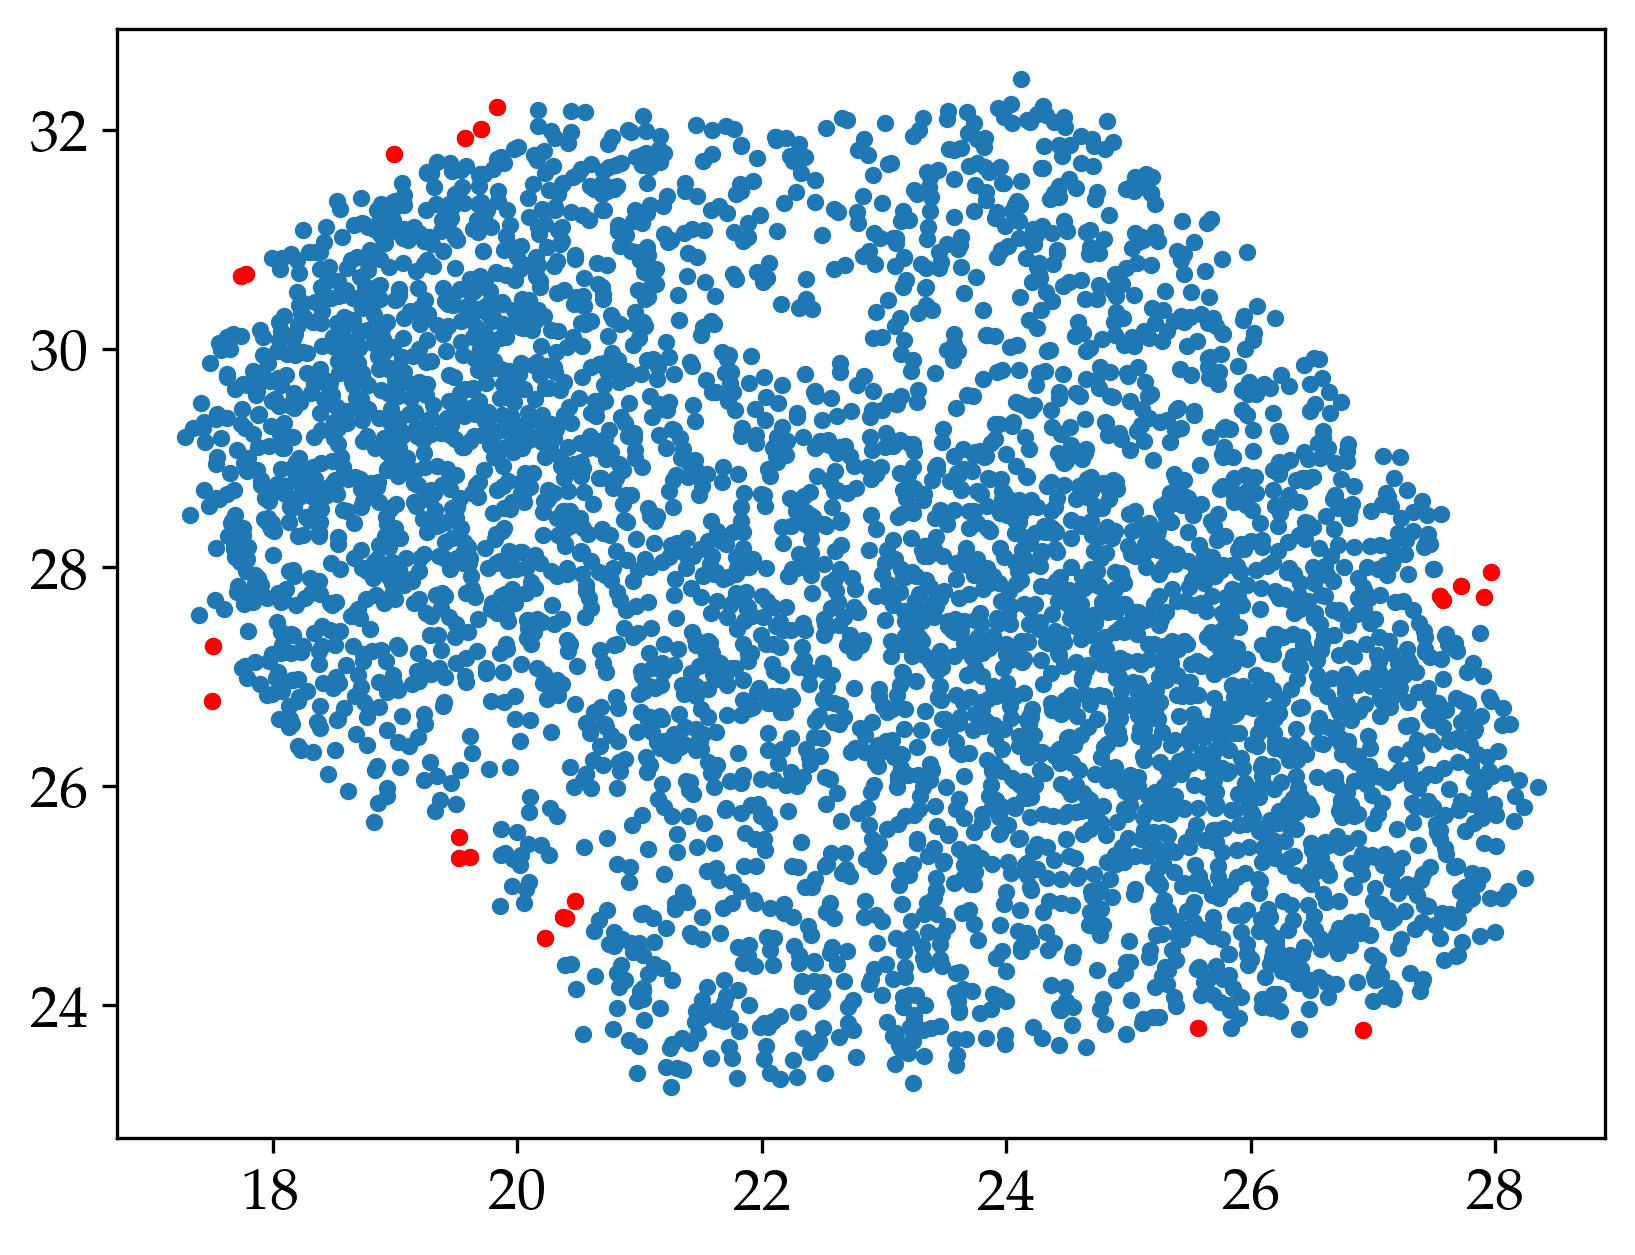

In [21]:
plt.scatter(file['embedding'][:, 0], file['embedding'][:, 1], s=10)
plt.scatter(file['embedding'][:, 0][file['outlier_mask']], file['embedding'][:, 1][file['outlier_mask']], s=10, c='red')

In [22]:
np.unique(file['categories'])

array([b'GAL', b'OTHER', b'QSO', b'SKY', b'STAR'], dtype=object)

In [23]:
import sys, os
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

from src.desiproc.build_matrix import build_matrix
import glob

out_dir = os.path.join(project_root, 'AssessingDesiData', 'data', 'processed')
night   = '20211110'
tile    = '10256'
bands   = ['B','R','Z']
wg, fp, iv, z, ze, ids, cat, petals = build_matrix(out_dir, night, tile, bands)

print("wave_grid:", wg.shape)
print("flux matrix:", fp.shape)
print("ivar matrix:", iv.shape)
print("z vector:", z.shape)
print("zerr vector:", ze.shape)
print("ids vector:", ids.shape)
print("cat matrix:", cat.shape)
print("petals matrix:", petals.shape)

wave_grid: (7958,)
flux matrix: (4196, 7958)
ivar matrix: (4196, 7958)
z vector: (4196,)
zerr vector: (4196,)
ids vector: (4196,)
cat matrix: (4196,)
petals matrix: (4196,)


In [24]:
import umap
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import connected_components

In [25]:
defaults = dict(n_neighbors=45, min_dist=1.0, n_components=3,
                        metric='cosine', n_jobs=-1)
reducer = umap.UMAP(**defaults)
emb = reducer.fit_transform(fp)

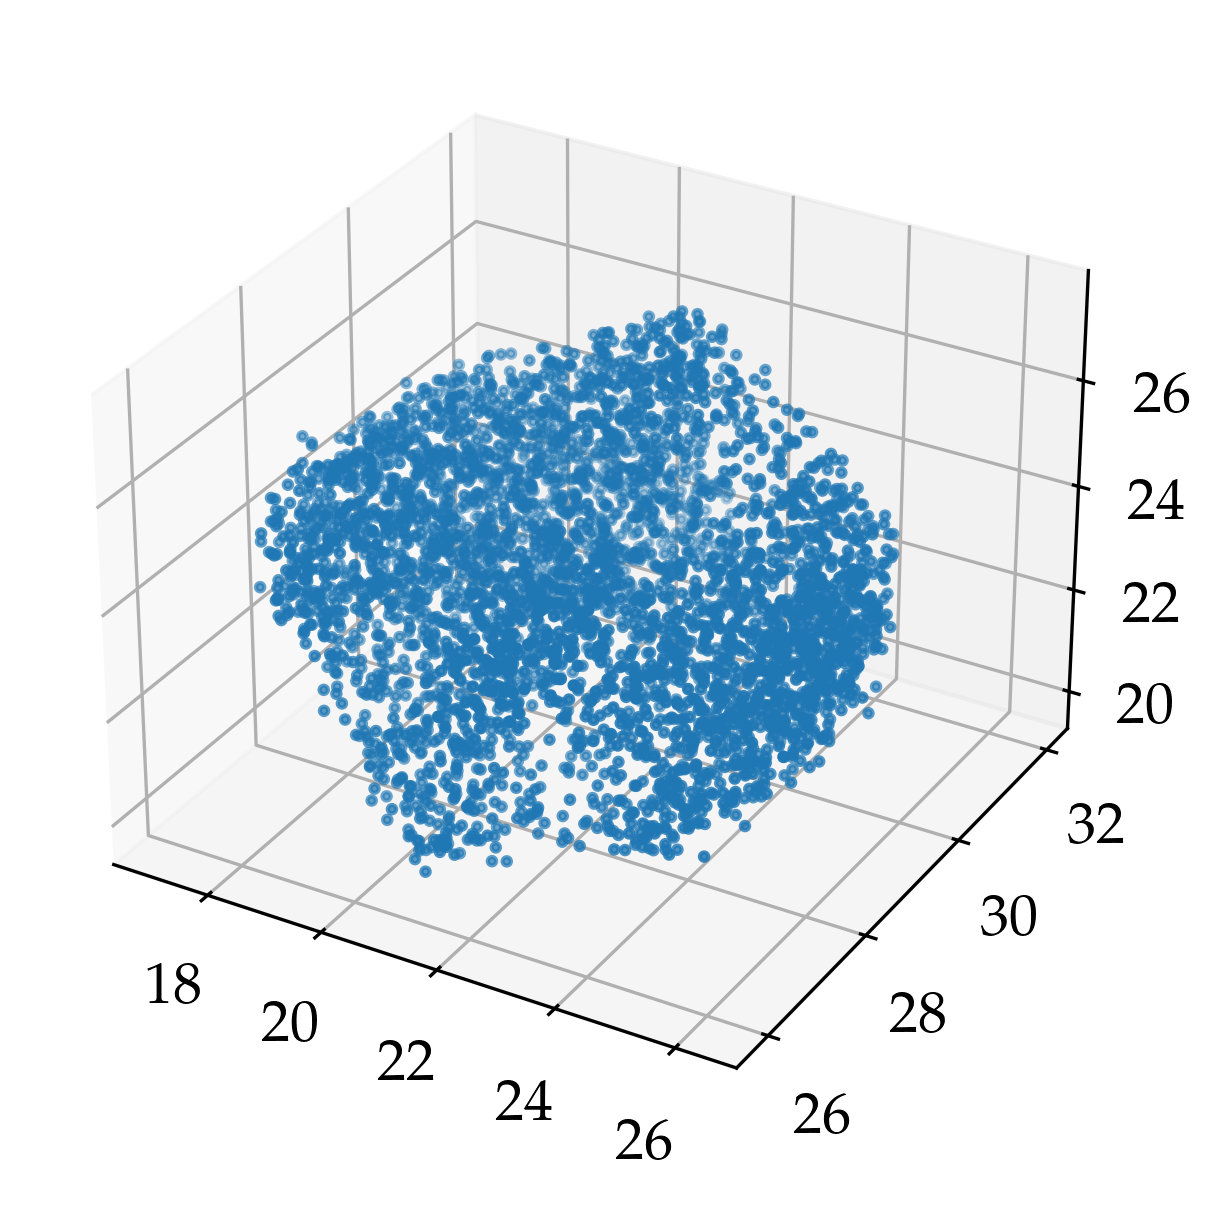

In [26]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], 'o', s=4)

In [27]:
link_length = 0.45

In [28]:
graph = radius_neighbors_graph(emb, radius=link_length,
                                       mode='connectivity', include_self=True,
                                       n_jobs=-1)
n_clusters, labels = connected_components(csgraph=graph,
                                                            directed=False,
                                                            return_labels=True)

In [29]:
min_cluster_size = 5

In [30]:
uniq, cnt = np.unique(labels, return_counts=True)
small = uniq[cnt <= min_cluster_size]
a = np.isin(labels, small)

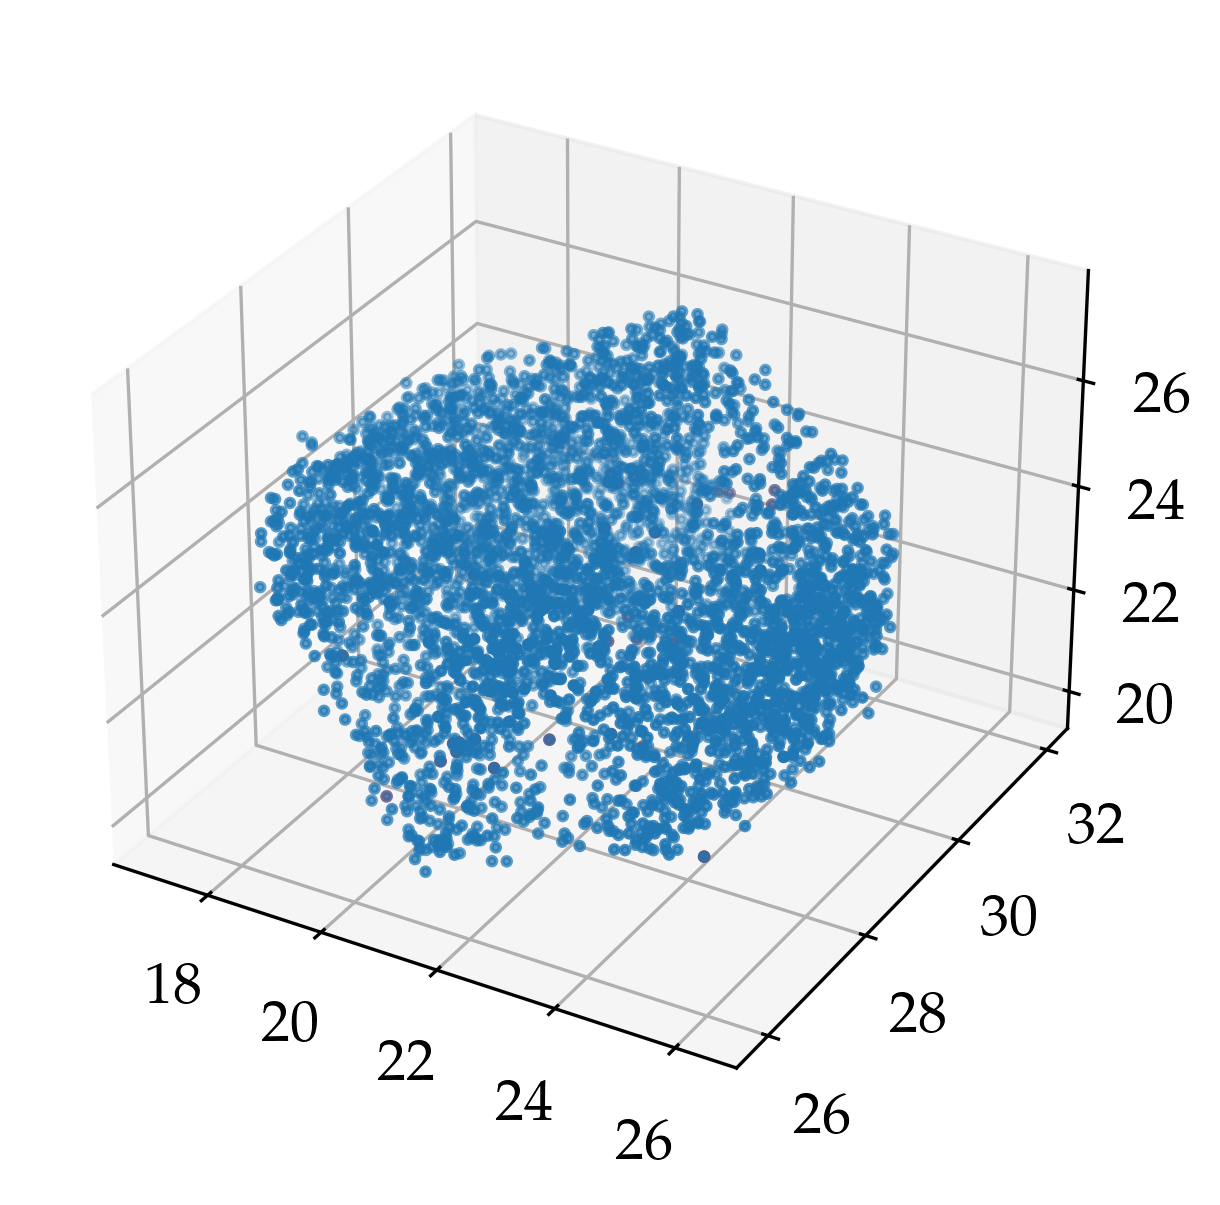

In [32]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], 'o', s=4)
ax.scatter(emb[:, 0][a], emb[:, 1][a], emb[:, 2][a], 'o', c='red', s=4)

----

In [121]:
import sys, os
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

from src.desiproc.build_matrix import build_matrix
import glob

out_dir = os.path.join(project_root, 'AssessingDesiData', 'data', 'processed')
night   = '20211130'
tile    = '5568'
bands   = ['B','R','Z']
wg, fp, iv, z, ze, ids, cat, petals = build_matrix(out_dir, night, tile, bands)

print("wave_grid:", wg.shape)
print("flux matrix:", fp.shape)
print("ivar matrix:", iv.shape)
print("z vector:", z.shape)
print("zerr vector:", ze.shape)
print("ids vector:", ids.shape)
print("cat matrix:", cat.shape)
print("petals matrix:", petals.shape)

wave_grid: (7958,)
flux matrix: (4220, 7958)
ivar matrix: (4220, 7958)
z vector: (4220,)
zerr vector: (4220,)
ids vector: (4220,)
cat matrix: (4220,)
petals matrix: (4220,)


In [122]:
defaults = dict(n_neighbors=45, min_dist=1.0, n_components=3,
                        metric='cosine', n_jobs=-1)
reducer = umap.UMAP(**defaults)
emb = reducer.fit_transform(fp)

In [123]:
link_length = 0.45
min_cluster_size = 5
graph = radius_neighbors_graph(emb, radius=link_length,
                                       mode='connectivity', include_self=True,
                                       n_jobs=-1)
n_clusters, labels = connected_components(csgraph=graph,
                                                            directed=False,
                                                            return_labels=True)
uniq, cnt = np.unique(labels, return_counts=True)
small = uniq[cnt <= min_cluster_size]
a = np.isin(labels, small)

In [124]:
categories = [c.decode('utf-8') if isinstance(c, (bytes, bytearray)) else str(c)
                  for c in cat]

In [125]:
a.sum()

21

MovieWriter ffmpeg unavailable; using Pillow instead.


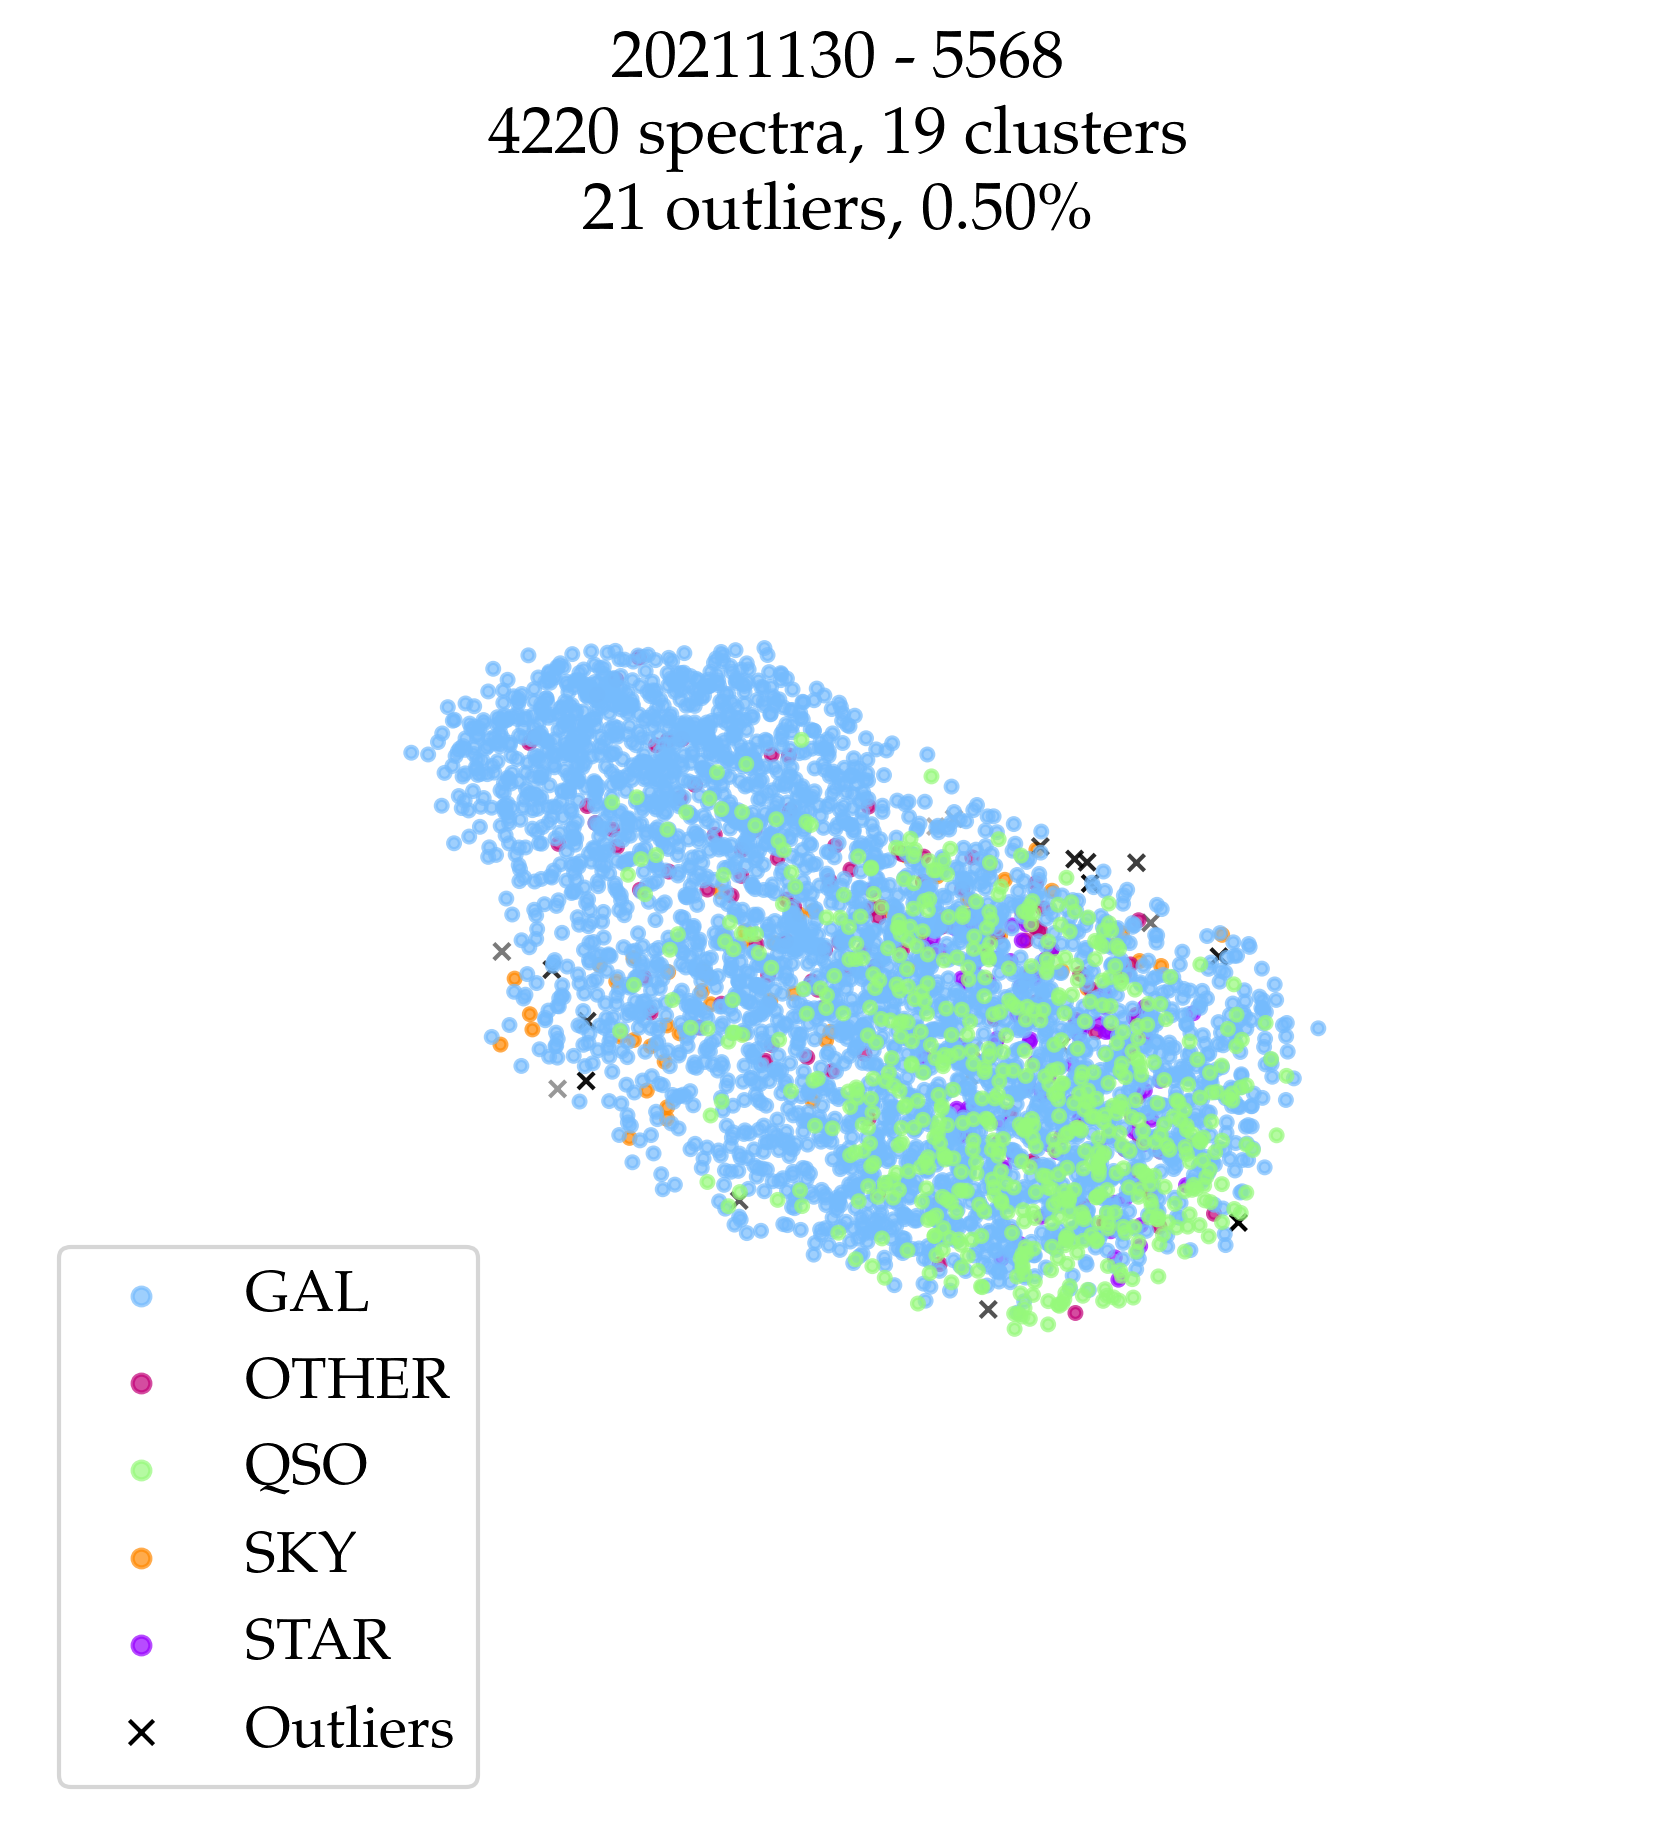

In [126]:
cat_array = np.array(categories)
outlier_mask = a

fig = plt.figure(figsize=(8,7))
ax  = fig.add_subplot(111, projection='3d')

unique_cats = sorted(np.unique(cat_array))
colors = ['#75bbfd', '#c20078', '#96f97b', '#ff8800', '#9900ff']

for i, c in enumerate(unique_cats):
    mask = (cat_array == c) & (~outlier_mask)
    ax.scatter(
        emb[mask, 0], emb[mask, 1], emb[mask, 2],
        s=8, color=colors[i], label=c, alpha=0.7
    )

if outlier_mask.any():
    ax.scatter(
        emb[outlier_mask, 0],
        emb[outlier_mask, 1],
        emb[outlier_mask, 2],
        s=15, marker='x', linewidths=1.0,
        color='black', label='Outliers'
    )

ax.legend(fontsize=14, loc='lower left', markerscale=1.5)

ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
plt.axis('off')

title  = f'{night} - {tile}\n'
title += f'{len(fp)} spectra, {n_clusters} clusters\n'
title += fr'{outlier_mask.sum()} outliers, {outlier_mask.mean()*100:.2f}\%'
ax.set_title(title, y=1.05, fontsize=16)

def update(frame):
    ax.view_init(azim=frame, elev=frame/2)

ani = animation.FuncAnimation(fig, update, frames=360, interval=120)
ani.save(f'umap_3d_{tile}.gif', fps=15, dpi=200)